# Sprint 1 - Configuração e versionamento

In [13]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [14]:
# Caminho base do projeto (pasta onde está este notebook)
base_dir = os.getcwd()
# Databricks
# base_dir = '/Workspace/Users/leonardobadell@protonmail.com/MIni-projeto-avaliativo-modulo-2'

# Caminhos das pastas com imagens
path_def_front = os.path.join(base_dir, 'def_front')
path_ok_front = os.path.join(base_dir, 'ok_front')

# Listar todos os arquivos de imagem de cada pasta
imagens_def = [os.path.join(path_def_front, f) for f in os.listdir(path_def_front) 
               if f.endswith(('.jpg', '.jpeg', '.png'))]
imagens_ok = [os.path.join(path_ok_front, f) for f in os.listdir(path_ok_front) 
              if f.endswith(('.jpg', '.jpeg', '.png'))]

# Criar DataFrame com Pandas
df_imagens = pd.DataFrame({
    'caminho': imagens_def + imagens_ok,
    'classe': ['def_front'] * len(imagens_def) + ['ok_front'] * len(imagens_ok)
})

# Criar label numérica usando np.where: 1 = defeito, 0 = ok
df_imagens['label'] = np.where(df_imagens['classe'] == 'def_front', 1, 0)

# Exibir informações do dataset
print(f"Total de imagens carregadas: {len(df_imagens)}")
print(f"\nDistribuição de classes:")
print(df_imagens['classe'].value_counts())
print(f"\nPrimeiras 5 linhas do dataset:")
display(df_imagens.head())

Total de imagens carregadas: 1300

Distribuição de classes:
classe
def_front    781
ok_front     519
Name: count, dtype: int64

Primeiras 5 linhas do dataset:


,caminho,classe,label
0,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
1,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
2,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
3,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1
4,c:\Users\leonardo.badell\MIni-projeto-avaliati...,def_front,1


# Sprint 2 - Análise exploratória clássica (OpenCV)

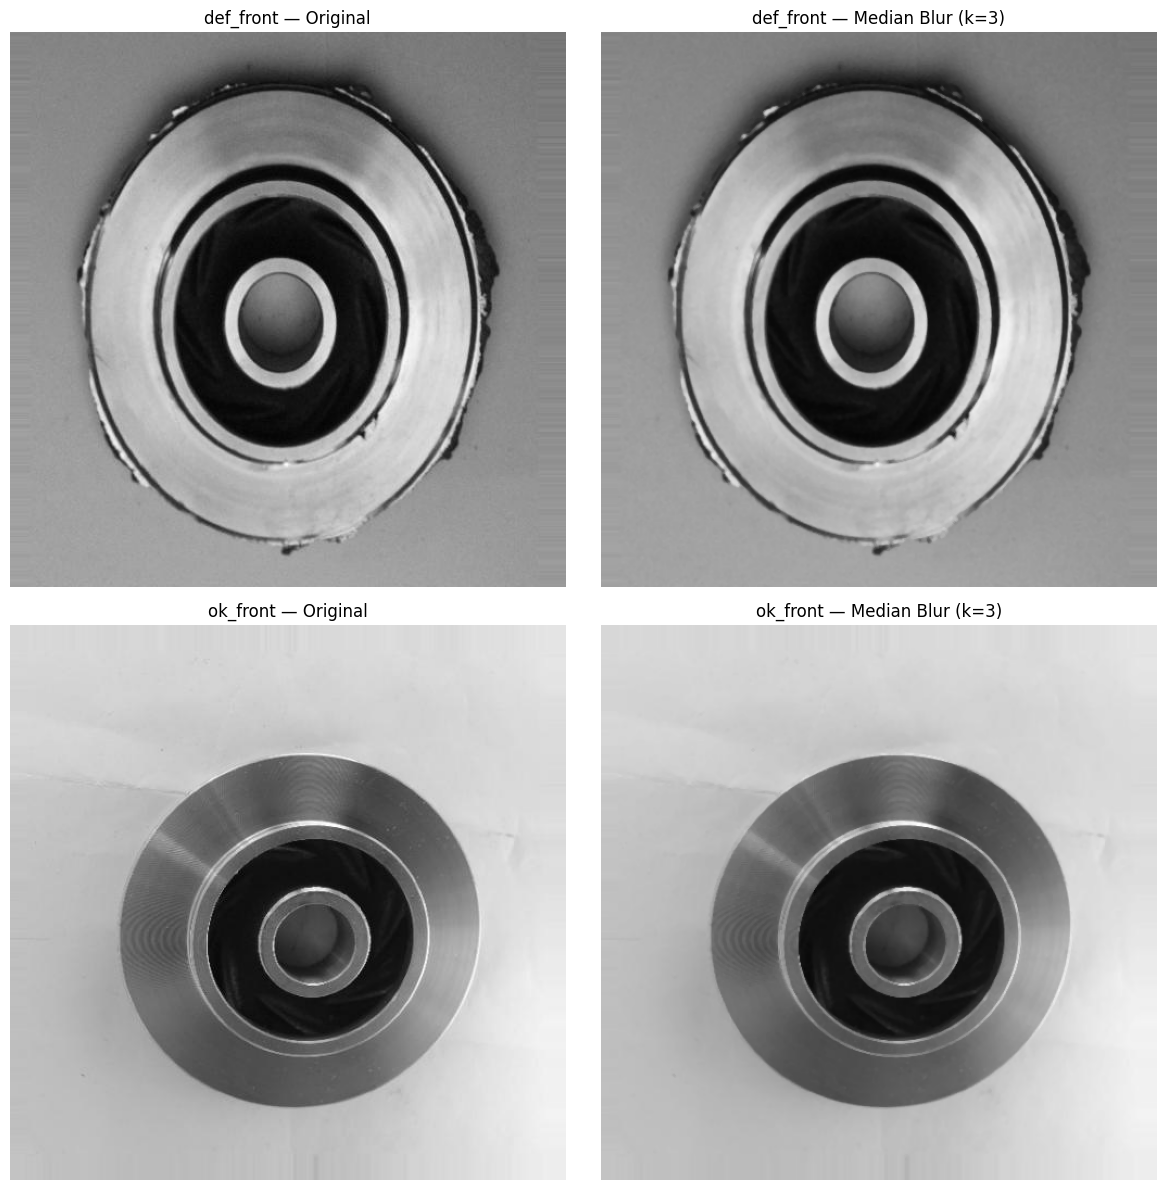

In [16]:
img_def_front = cv2.imread(imagens_def[0])
img_ok_front = cv2.imread(imagens_ok[0])

def aplicar_median_blur(img, k=3):
    img_u8 = img.astype(np.uint8)
    return cv2.medianBlur(img_u8, k)

img_def_blur = aplicar_median_blur(img_def_front)
img_ok_blur = aplicar_median_blur(img_ok_front)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img_def_front, cmap='gray')
axes[0, 0].set_title('def_front — Original')
axes[0, 1].imshow(img_def_blur, cmap='gray')
axes[0, 1].set_title('def_front — Median Blur (k=3)')

axes[1, 0].imshow(img_ok_front, cmap='gray')
axes[1, 0].set_title('ok_front — Original')
axes[1, 1].imshow(img_ok_blur, cmap='gray')
axes[1, 1].set_title('ok_front — Median Blur (k=3)')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

def_front — média: 131.58 | desvio padrão: 55.93
ok_front  — média: 167.15 | desvio padrão: 62.90
Teste KS (def_front vs ok_front): estatística=0.4598, p-valor=0.0000


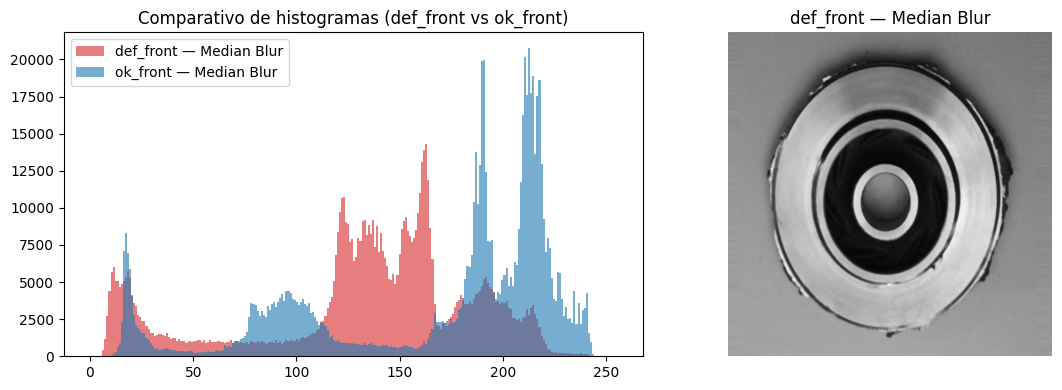

In [17]:
# --- Comparativo estatístico e histogramas: def_front vs ok_front (Median Blur) ---
media_def, desvio_def = img_def_blur.mean(), img_def_blur.std()
media_ok, desvio_ok = img_ok_blur.mean(), img_ok_blur.std()
estatistica_ks, p_valor = stats.ks_2samp(img_def_blur.ravel(), img_ok_blur.ravel())

print(f"def_front — média: {media_def:.2f} | desvio padrão: {desvio_def:.2f}")
print(f"ok_front  — média: {media_ok:.2f} | desvio padrão: {desvio_ok:.2f}")
print(f"Teste KS (def_front vs ok_front): estatística={estatistica_ks:.4f}, p-valor={p_valor:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_def_blur.ravel(), bins=256, range=(0, 255), color='tab:red', alpha=0.6, label='def_front — Median Blur')
axes[0].hist(img_ok_blur.ravel(), bins=256, range=(0, 255), color='tab:blue', alpha=0.6, label='ok_front — Median Blur')
axes[0].set_title('Comparativo de histogramas (def_front vs ok_front)')
axes[0].legend()

axes[1].imshow(img_def_blur, cmap='gray')
axes[1].set_title('def_front — Median Blur')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Sprint 3 - Destaque de características

,classe,limiar_otsu,area_branca_%,borda_media,borda_desvio
0,def_front,95.0,79.97,4.30,11.04
1,ok_front,140.0,71.15,2.15,7.73


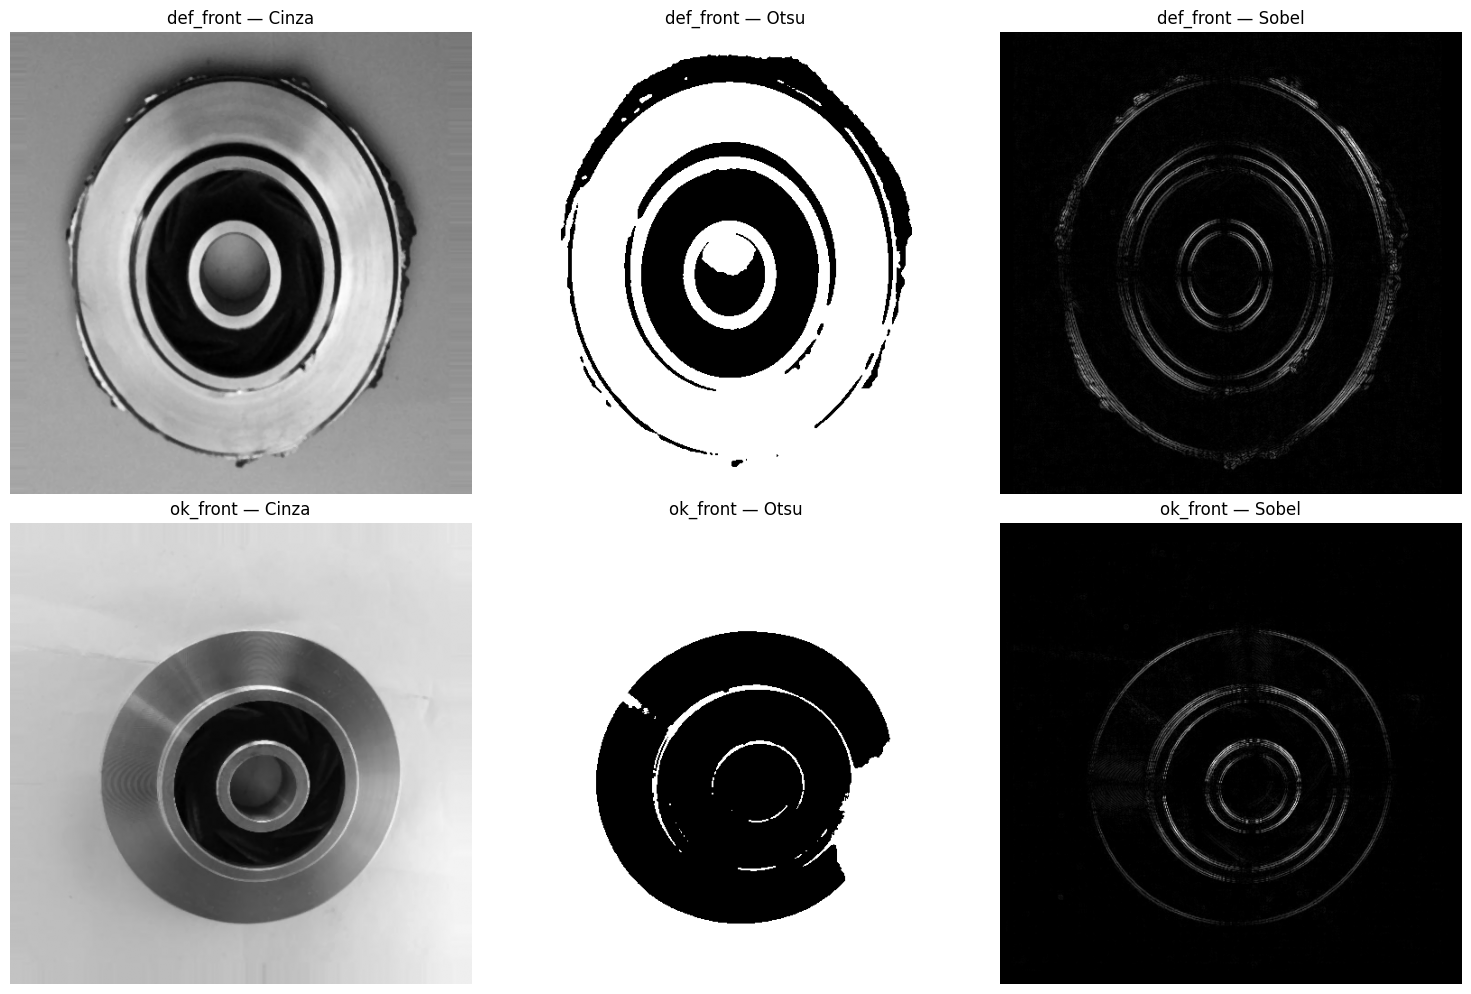

In [18]:
gray_def = cv2.cvtColor(img_def_blur, cv2.COLOR_BGR2GRAY)
gray_ok = cv2.cvtColor(img_ok_blur, cv2.COLOR_BGR2GRAY)

# A. THRESHOLDING (Otsu): separa a peça do fundo escolhendo o limiar automaticamente
limiar_def, thresh_def = cv2.threshold(gray_def, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
limiar_ok, thresh_ok = cv2.threshold(gray_ok, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# B. SOBEL: destaca apenas os contornos, o mesmo princípio que uma CNN aprende sozinha
sobel_def = cv2.convertScaleAbs(cv2.Sobel(gray_def, cv2.CV_64F, 1, 1, ksize=3))
sobel_ok = cv2.convertScaleAbs(cv2.Sobel(gray_ok, cv2.CV_64F, 1, 1, ksize=3))

# C. COMPARATIVO estatístico com pandas
df_features = pd.DataFrame({
    'classe': ['def_front', 'ok_front'],
    'limiar_otsu': [limiar_def, limiar_ok],
    'area_branca_%': [(thresh_def > 0).mean() * 100, (thresh_ok > 0).mean() * 100],
    'borda_media': [sobel_def.mean(), sobel_ok.mean()],
    'borda_desvio': [sobel_def.std(), sobel_ok.std()]
})
display(df_features.round(2))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(gray_def, cmap='gray')
axes[0, 0].set_title('def_front — Cinza')
axes[0, 1].imshow(thresh_def, cmap='gray')
axes[0, 1].set_title('def_front — Otsu')
axes[0, 2].imshow(sobel_def, cmap='gray')
axes[0, 2].set_title('def_front — Sobel')
axes[1, 0].imshow(gray_ok, cmap='gray')
axes[1, 0].set_title('ok_front — Cinza')
axes[1, 1].imshow(thresh_ok, cmap='gray')
axes[1, 1].set_title('ok_front — Otsu')
axes[1, 2].imshow(sobel_ok, cmap='gray')
axes[1, 2].set_title('ok_front — Sobel')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Sprint 4 - Ingestão de dados e augmentation (Keras)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.
Classes encontradas: ['def_front', 'ok_front']


,classe,quantidade_treino,percentual_treino,quantidade_validacao,percentual_validacao
0,ok_front,420,40.38,260,100.0


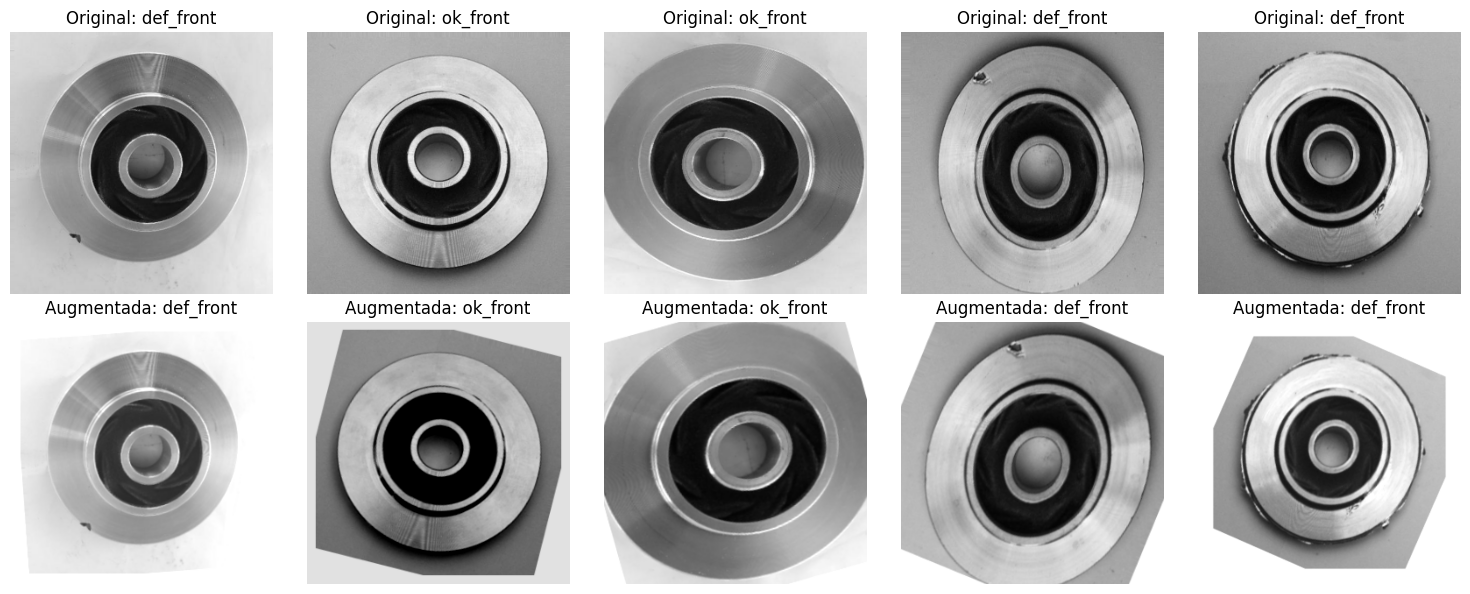

In [19]:

# ============================================================
# SPRINT 4 — Ingestão de dados e augmentation (Keras)
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 300
BATCH_SIZE = 32
SEED = 123

# ------------------------------------------------------------
# 1) Ingestão dos dados
# ------------------------------------------------------------

train_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training",
    label_mode="binary"
)

val_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    validation_split=0.2,
    subset="validation",
    label_mode="binary"
)

class_names = train_ds.class_names

print("Classes encontradas:", class_names)


# ------------------------------------------------------------
# 2) Verificação da distribuição das classes
# ------------------------------------------------------------

def distribuicao_classes(dataset, class_names):

    labels = np.concatenate([
        y.numpy().flatten()
        for _, y in dataset
    ]).astype(int)

    df = pd.DataFrame({
        "label": labels
    })

    df["classe"] = df["label"].map(
        dict(enumerate(class_names))
    )

    resumo = (
        df.groupby("classe")
          .size()
          .reset_index(name="quantidade")
    )

    resumo["percentual"] = (
        resumo["quantidade"]
        / resumo["quantidade"].sum()
        * 100
    ).round(2)

    return resumo


df_train = distribuicao_classes(
    train_ds,
    class_names
)

df_val = distribuicao_classes(
    val_ds,
    class_names
)

df_distribuicao = df_train.merge(
    df_val,
    on="classe",
    suffixes=("_treino", "_validacao")
)

display(df_distribuicao)


# ------------------------------------------------------------
# 3) Data augmentation
#    Aplicado somente às imagens de treinamento
# ------------------------------------------------------------

data_augmentation = keras.Sequential([

    layers.RandomRotation(
        0.10,
        fill_mode="constant",
        fill_value=255
    ),

    layers.RandomZoom(
        0.15,
        fill_mode="constant",
        fill_value=255
    ),

    layers.RandomBrightness(0.2),

    layers.RandomContrast(0.2),

    layers.RandomFlip("horizontal")
])


# ------------------------------------------------------------
# 4) Checagem visual
#    Linha 1 = original
#    Linha 2 = augmentation da mesma imagem
# ------------------------------------------------------------

for images, labels in train_ds.take(1):

    augmented = data_augmentation(
        images[:5],
        training=True
    )

    plt.figure(
        figsize=(15, 6)
    )

    for i in range(5):

        rotulo = int(
            labels[i].numpy()[0]
        )

        # Original
        plt.subplot(
            2,
            5,
            i + 1
        )

        plt.imshow(
            images[i]
            .numpy()
            .astype("uint8")
        )

        plt.title(
            f"Original: {class_names[rotulo]}"
        )

        plt.axis("off")

        # Augmentada
        plt.subplot(
            2,
            5,
            i + 6
        )

        plt.imshow(
            np.clip(
                augmented[i].numpy(),
                0,
                255
            ).astype("uint8")
        )

        plt.title(
            f"Augmentada: {class_names[rotulo]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Sprint 5 - A arquitetura CNN e treinamento

In [20]:
model = keras.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(
        16,
        3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dropout(0.2),

    layers.Dense(
        512,
        activation="relu"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
EPOCHS = 80

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 451ms/step - accuracy: 0.5625 - loss: 1.0594 - val_accuracy: 0.0000e+00 - val_loss: 0.7821
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 439ms/step - accuracy: 0.6404 - loss: 0.6304 - val_accuracy: 0.6385 - val_loss: 0.6898
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 430ms/step - accuracy: 0.6663 - loss: 0.6046 - val_accuracy: 0.6462 - val_loss: 0.7513
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 439ms/step - accuracy: 0.7125 - loss: 0.5609 - val_accuracy: 0.8500 - val_loss: 0.4535
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 420ms/step - accuracy: 0.7202 - loss: 0.5447 - val_accuracy: 0.7115 - val_loss: 0.6246
Epoch 6/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 463ms/step - accuracy: 0.7192 - loss: 0.5195 - val_accuracy: 0.9192 - val_loss: 0.4357
Epoch 7/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 456ms/step - accuracy: 0.7154 - loss: 0.5404 - val_accuracy: 0.9654 - val_loss: 0.2887
Epoch 8/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 505ms/step - accuracy: 0.7337 - loss: 0.5247 - val_

# Sprint 6 - Auditoria e gravação